# Telco Customer Churn — Exploration


This notebook explores the raw Telco Customer Churn dataset, documents cleaning
decisions with reasoning (not just code), and prototypes the feature engineering
that gets ported into `src/preprocessing.py` for reuse in the modeling pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

## 1. Missing Values

`df.isna()` alone won't catch everything here: `TotalCharges` is loaded as an
`object` (string) column, and some rows hold an empty string `""` rather than
a true `NaN`. A naive `isna().sum()` would report zero missing values for that
column and silently hide the problem — so we check for blank/whitespace
strings explicitly before deciding anything.

In [2]:
print("Naive isna().sum() (misses blank strings):")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nTotalCharges dtype:", df["TotalCharges"].dtype)
blank_mask = df["TotalCharges"].astype(str).str.strip() == ""
print(f"Blank-string rows in TotalCharges: {blank_mask.sum()}")
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Naive isna().sum() (misses blank strings):
Series([], dtype: int64)

TotalCharges dtype: str
Blank-string rows in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Finding:** all 11 blank `TotalCharges` rows have `tenure == 0` — these are
brand-new customers who haven't been billed yet, so `TotalCharges` is
legitimately "not applicable" rather than a data-entry error.

**Decision:** coerce `TotalCharges` to numeric (`errors="coerce"` turns the
blanks into `NaN`), then impute those 11 rows with `0` — that's the correct
value for a customer with zero tenure and zero billing history, not a guess.
Dropping the rows would lose real (if new) customers for no benefit.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Confirm blanks -> NaN, all at tenure == 0:")
print(df.loc[df["TotalCharges"].isna(), "tenure"].unique())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Remaining missing values in TotalCharges:", df["TotalCharges"].isna().sum())

Confirm blanks -> NaN, all at tenure == 0:
[0]
Remaining missing values in TotalCharges: 0


## 2. Target Class Balance

Churn is the business-relevant outcome we're predicting. Checking the balance
now determines whether accuracy alone will be a misleading metric later.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


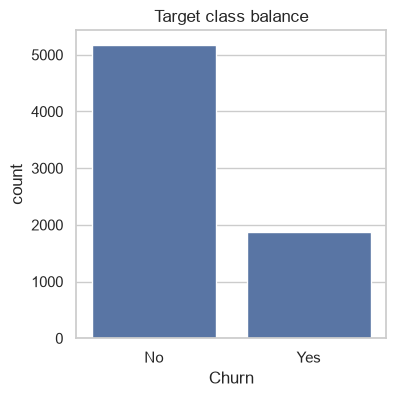

In [4]:
counts = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Target class balance")
plt.show()

**Finding:** ~73.5% No / ~26.5% Yes — moderately imbalanced. Not extreme
(like fraud at <1%), but enough that plain accuracy would reward a model that
just predicts "No churn" for everyone (~73.5% accuracy while catching zero
at-risk customers, which defeats the business purpose). This motivates using
`stratify=y` in train/test splits and cross-validation folds, and evaluating
with precision/recall/F1/ROC-AUC instead of accuracy alone in the modeling
step.

## 3. Numeric Feature Distributions vs. Churn

Looking at `tenure`, `MonthlyCharges`, and `TotalCharges` split by churn status
to see which numeric features look predictive before we even train a model.

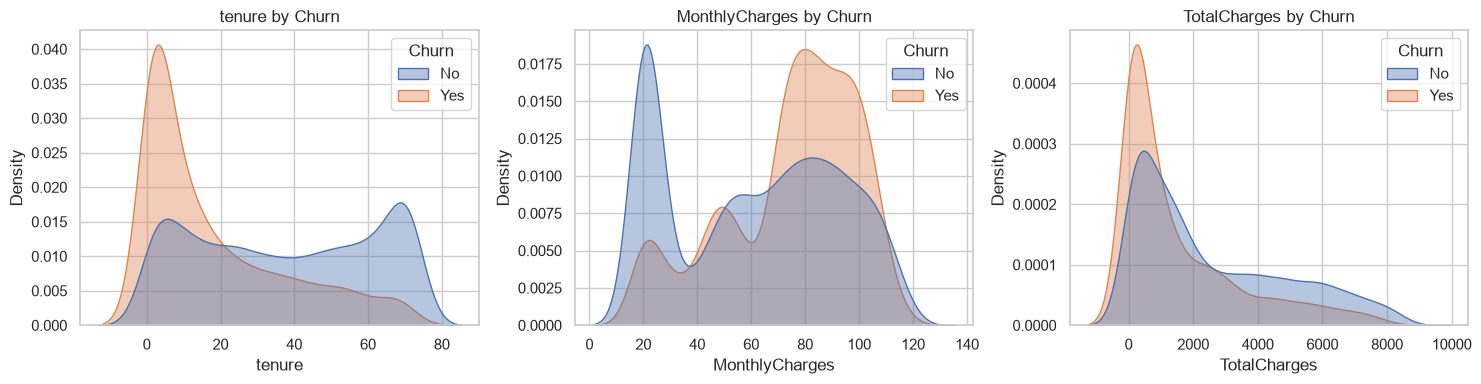

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


In [5]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", ax=ax, fill=True, common_norm=False, alpha=0.4)
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

df.groupby("Churn")[numeric_cols].mean().round(2)

**Finding:** churned customers skew heavily toward *low tenure* (they leave
early — new customers are the highest-risk group) and *higher
MonthlyCharges* (pricier plans correlate with churn, possibly a value
perception issue). `TotalCharges` is a function of `tenure × MonthlyCharges`
roughly, so it's less independently informative and is a candidate for
dropping or de-emphasizing to reduce redundancy with `tenure`.

## 4. Correlation with Target

Encoding `Churn` as a binary 0/1 to compute point-biserial-style correlations
against the numeric features (and one-hot encoded categoricals) gives a quick
ranked view of what's associated with churn before modeling.

In [6]:
churn_binary = (df["Churn"] == "Yes").astype(int)
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])
encoded_preview = pd.get_dummies(df[cat_cols], drop_first=False)
corr_df = pd.concat([df[numeric_cols], encoded_preview], axis=1)
corr_with_target = corr_df.corrwith(churn_binary).sort_values(key=abs, ascending=False)
corr_with_target.head(15)

D:\Users\udays\AppData\Local\Temp\ipykernel_13600\2004180160.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])


Contract_Month-to-month                 0.405103
tenure                                 -0.352229
OnlineSecurity_No                       0.342637
TechSupport_No                          0.337281
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
OnlineBackup_No                         0.268005
DeviceProtection_No                     0.252481
InternetService_No                     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
StreamingTV_No internet service        -0.227890
OnlineBackup_No internet service       -0.227890
OnlineSecurity_No internet service     -0.227890
dtype: float64

**Finding:** `Contract_Month-to-month` and low `tenure` are the strongest
positive correlates of churn; `Contract_Two year` and long `tenure` are the
strongest negative correlates. This makes business sense — customers without
a long-term commitment are free to leave anytime, so contract type is
likely to be one of the most important model features.

## 5. Leakage Check

`customerID` is a unique identifier with no predictive signal and would only
add noise (or in the worst case let a model "memorize" rows) — it must be
dropped. No other column in this dataset is computed *after* or *because of*
churn (unlike, e.g., a "cancellation date" field would be), so there's no
other leakage risk here.

## 6. Encoding Strategy

Most categorical columns here are **nominal** (no inherent order: `gender`,
`InternetService`, `PaymentMethod`, the various "Yes/No/No internet service"
service columns, etc.). Label-encoding these as integers (e.g. `DSL=0,
Fiber=1, No=2`) would invent a false ordinal relationship that tree models
can exploit spuriously and that linear/distance-based models would weight
incorrectly. **One-hot encoding** is the correct choice for these.

The exception is genuinely **binary** Yes/No columns (`Partner`,
`Dependents`, `PhoneService`, `PaperlessBilling`, and the target `Churn`
itself) — for a true two-level category, a single 0/1 column *is* one-hot
encoding (minus the redundant second column), so we map these directly
rather than running them through `get_dummies` and dropping a column
after the fact.

`Contract` (Month-to-month / One year / Two year) is nominal here too, not
ordinal — while there's a natural length ordering, we don't want to assume
the *effect* on churn is linear in that ordering, so it goes through
one-hot encoding as well and lets the model learn each level's effect
independently.

## 7. Feature Engineering

Two derived features add signal beyond the raw columns:

- **`tenure_bucket`**: bucketing `tenure` into groups (0-12, 13-24, 25-48,
  49+ months) captures the non-linear "new customers churn most" pattern
  from the EDA above in a form that's easier for a linear model to use
  directly (a tree model can already split on raw `tenure`, but this still
  helps interpretability).
- **`total_services`**: a count of how many of the 6 optional add-on
  services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, `StreamingMovies`) a customer has
  subscribed to. This captures "engagement depth" as a single number —
  the hypothesis being that more invested customers churn less.

## 8. Final Pipeline

The cleaning/encoding/feature-engineering logic above has been ported into
`src/preprocessing.py` as `load_and_preprocess(raw_path)`, so it's reusable
by the training pipeline instead of copy-pasted from this notebook. Calling
it here as a sanity check that notebook prototyping and the shipped module
agree.

In [7]:
import sys
sys.path.append("..")
from src.preprocessing import load_and_preprocess

X, y = load_and_preprocess("../data/raw/Telco-Customer-Churn.csv")
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True).round(4))
X.head()

X shape: (7043, 46)
y distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,total_services,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_0-12,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49+
0,0,1,0,1,0,1,29.85,29.85,1,True,False,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,2,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False
2,0,0,0,2,1,1,53.85,108.15,2,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,True,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,3,False,True,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False
4,0,0,0,2,1,1,70.70,151.65,0,True,False,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False
